In [1]:
from pathlib import Path

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

%cd {project_root}

/home/ubuntu/Psi0


/home/ubuntu/Psi0/.venv-psi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch
import numpy as np
from pathlib import Path
from psi.utils import parse_args_to_tyro_config, seed_everything, move_to_device, batchify
from psi.config.config import LaunchConfig

In [3]:
ckpt_step = 40000
run_dir = Path(".runs/finetune/pick-toys.real.flow1000.cosine.lr1.0e-04.b16.gpus1.2604101000")
assert run_dir.exists(), f"Run dir not found: {run_dir}"

config_: LaunchConfig = parse_args_to_tyro_config(run_dir / "argv.txt")  # type: ignore
conf = (run_dir / "run_config.json").open("r").read()
launch_config = config_.model_validate_json(conf)

print(f"run_dir={run_dir}")
print(f"ckpt_step={ckpt_step}")
print(f"exp={launch_config.exp}")
print(f"dataset={launch_config.data.transform.repack.dataset_name}")

run_dir=.runs/finetune/pick-toys.real.flow1000.cosine.lr1.0e-04.b16.gpus1.2604101000
ckpt_step=40000
exp=pick-toys
dataset=real


In [4]:
seed_everything(launch_config.seed or 42)

In [5]:
device = "cuda:0"

In [6]:
from psi.models.psi0 import Psi0Model 
psi0 = Psi0Model.from_pretrained(run_dir, ckpt_step, launch_config, device=device)
psi0.to(device)
psi0.eval()
print("Model loaded successfully.")

/home/ubuntu/Psi0/.venv-psi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are attempting to use Flash Attention 2 without specifying a torch dtype. This might lead to unexpected behaviour
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


[17:04:34 04/10] INFO     | >> [*] Resized model token embeddings to 153792                            ]8;id=975055;file:///home/ubuntu/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=401768;file:///home/ubuntu/Psi0/src/psi/models/psi0.py#1557\1557]8;;\

[17:04:35 04/10] INFO     | >> [*] loaded vlm_backbone checkpoint successfully.                        ]8;id=993752;file:///home/ubuntu/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=976513;file:///home/ubuntu/Psi0/src/psi/models/psi0.py#1560\1560]8;;\

[17:04:36 04/10] INFO     | >> [*] Total ActionTransformerModel parameters: 497,719,256                ]8;id=120785;file:///home/ubuntu/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=101754;file:///home/ubuntu/Psi0/src/psi/models/psi0.py#1517\1517]8;;\

                 INFO     | >> [*] Total VLM Backbone parameters: 2,131,333,120                        ]8;id=161681;file:///home/ubuntu/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=974824;file:///home/ubuntu/Psi0/src/psi/models/psi0.py#1521\1521]8;;\

[17:04:37 04/10] INFO     | >> [*] loaded action head checkpoint successfully.                         ]8;id=422394;file:///home/ubuntu/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=225693;file:///home/ubuntu/Psi0/src/psi/models/psi0.py#1578\1578]8;;\

Model loaded successfully.


In [7]:
from psi.config.data_lerobot import LerobotDataConfig
data_cfg: LerobotDataConfig = launch_config.data # type: ignore

from psi.config.model_psi0 import Psi0ModelConfig
model_cfg: Psi0ModelConfig = launch_config.model # type: ignore

In [8]:
maxmin = data_cfg.transform.field

In [9]:
transform_kwargs=dict(
    vlm_processor=psi0.vlm_processor,
)

In [10]:
split = "train"
dataset = data_cfg(split=split, transform_kwargs=transform_kwargs)
print(f"split={split}")
print(f"num_frames={len(dataset)}")
print(f"num_episodes={dataset.raw_dataset.meta.total_episodes}")

[17:04:53 04/10] INFO     | >> PyTorch version 2.7.0 available.                                        ]8;id=557966;file:///home/ubuntu/Psi0/.venv-psi/lib/python3.10/site-packages/datasets/config.py\config.py]8;;\:]8;id=879618;file:///home/ubuntu/Psi0/.venv-psi/lib/python3.10/site-packages/datasets/config.py#54\54]8;;\

split=train
num_frames=127382
num_episodes=80


In [11]:
dataset.raw_dataset.meta

LeRobotDatasetMetadata({
    Repository ID: 'Pick_toys_into_box_and_lift_and_turn_and_put_on_the_chair_new_target_yaw',
    Total episodes: '80',
    Total frames: '127382',
    Features: '['observation.images.egocentric', 'states', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'next.done', 'task_index']',
})',

In [12]:
eps_idx = 0
# Change this if you want to inspect another episode.
print(f"eps_idx={eps_idx}")

eps_idx=0


In [13]:
start_frame_idx = dataset.raw_dataset.base_dataset.episode_data_index["from"][eps_idx].item()
end_frame_idx = dataset.raw_dataset.base_dataset.episode_data_index["to"][eps_idx].item()
print(f"episode frame range: [{start_frame_idx}, {end_frame_idx})")

episode frame range: [0, 1903)


In [14]:
print(start_frame_idx, end_frame_idx)
print("num frames in this episode:", end_frame_idx - start_frame_idx)

0 1903
num frames in this episode: 1903


In [15]:
avg_action_errors_denormed_list = []

labels_denormed = [
    "hand_joints",
    "arm_joints",
    "torsor_roll", # torso rpy
    "torsor_pitch", # torso rpy
    "torsor_yaw", # torso rpy
    "height",
    "vx",
    "vy",
    "torso_vyaw",
    "target_yaw",
]

stride = 4
for i in range(start_frame_idx, end_frame_idx, stride):
    frame = dataset[i]
    # print(list(frame.keys()))
    images = frame["raw_images"]
    batch_images = [images] # List[List[PIL.Image.Image]] batch size == 1
    instruction = frame['instruction']
    batch_instructions = [instruction] # List[str]

    states = frame['states'] # (H, D)
    batch_states = torch.from_numpy(states).unsqueeze(0).to(device) # (B, H, D)

    pred_actions = psi0.predict_action(
        observations=batch_images, 
        states=batch_states, 
        instructions=batch_instructions, 
        num_inference_steps=10, 
        traj2ds=None
    )
    
    gt_action = torch.from_numpy(frame["raw_actions"]).unsqueeze(0).to(device) # (1, Tp, Da)
    denormalized_pred_actions = maxmin.denormalize(pred_actions)

    error = denormalized_pred_actions - gt_action # (1, Tp, Da)
    error_l1 = error.detach().abs().cpu().numpy().reshape(-1, gt_action.shape[-1]) # (Tp, Da)

    avg_action_errors_denormed = error_l1.mean(0)
    avg_action_errors_denormed_list.append(avg_action_errors_denormed)

    # break

avg_action_errors_denormed_list = np.stack(avg_action_errors_denormed_list, axis=0)
avg_action_errors_denormed = avg_action_errors_denormed_list.mean(axis=0)

avg_action_errors_denormed_split = np.split(
    avg_action_errors_denormed, [14, 28, 31, 32, 33, 34, 35], axis=-1
)

print("\n---------------------------\n")
for i in range(len(avg_action_errors_denormed_split)):
    print(f"denormed_err_l1_{labels_denormed[i]} {avg_action_errors_denormed_split[i].shape}:  {np.linalg.norm(avg_action_errors_denormed_split[i])}")



---------------------------

denormed_err_l1_hand_joints (14,):  0.23646555840969086
denormed_err_l1_arm_joints (14,):  0.3294025659561157
denormed_err_l1_torsor_roll (3,):  0.054599300026893616
denormed_err_l1_torsor_pitch (1,):  0.00920182280242443
denormed_err_l1_torsor_yaw (1,):  0.015389814041554928
denormed_err_l1_height (1,):  0.004204407334327698
denormed_err_l1_vx (1,):  0.009557981044054031
denormed_err_l1_vy (1,):  0.05962073430418968


In [16]:
!uv pip install matplotlib

Using Python 3.10.12 environment at: .venv-psi
Resolved 11 packages in 2.28s                                        
⠙ Preparing packages... (0/6)                                                   
⠙ Preparing packages... (0/6)-------------------     0 B/8.13 KiB            
⠙ Preparing packages... (0/6)-------------------     0 B/8.13 KiB            
cycler               ------------------------------     0 B/8.13 KiB
⠙ Preparing packages... (0/6)-------------------     0 B/317.41 KiB          
cycler               ------------------------------     0 B/8.13 KiB
⠙ Preparing packages... (0/6)-------------------     0 B/317.41 KiB          
cycler               ------------------------------     0 B/8.13 KiB
⠙ Preparing packages... (0/6)-------------------     0 B/317.41 KiB          
cycler               ------------------------------     0 B/8.13 KiB
pyparsing            ------------------------------     0 B/119.90 KiB
⠙ Preparing packages... (0/6)-------------------     0 B/317.41 K

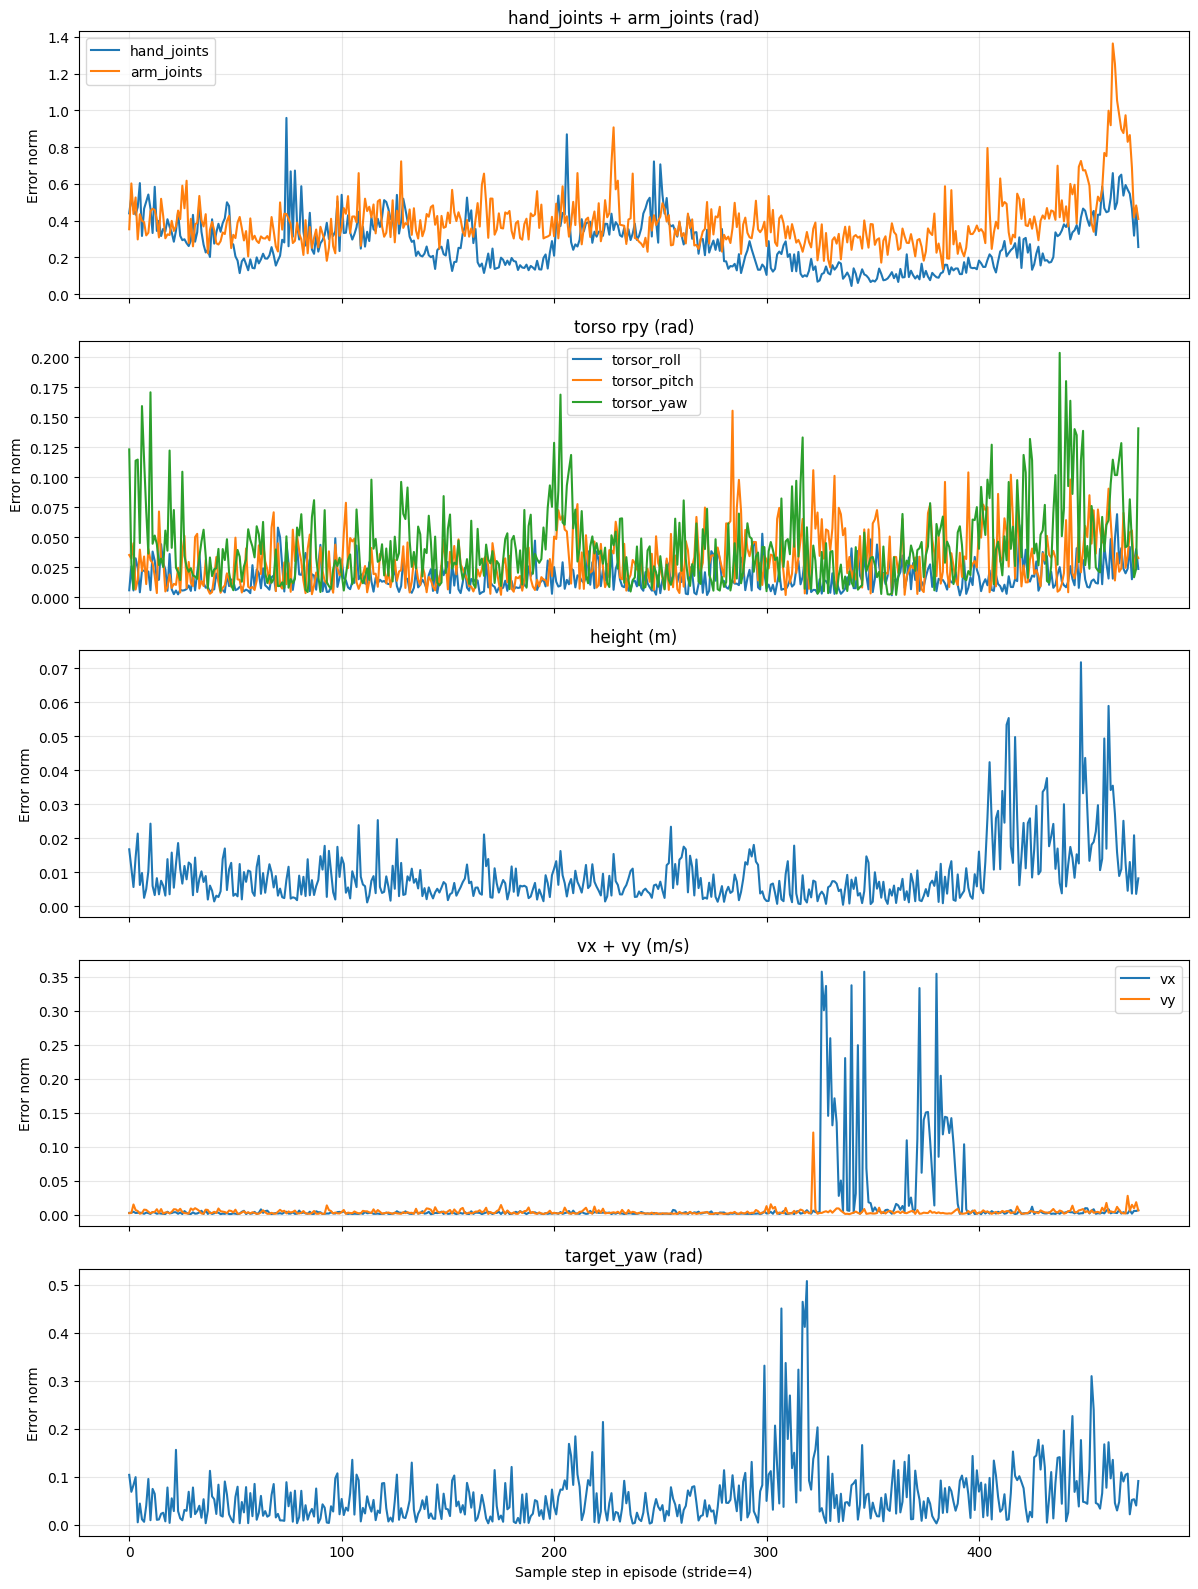

In [17]:
import matplotlib.pyplot as plt

# avg_action_errors_denormed_list: (T, 36)
group_slices = [14, 28, 29, 30, 31, 32, 33, 34, 35]
error_groups = np.split(avg_action_errors_denormed_list, group_slices, axis=-1)

# One scalar curve per semantic group
per_label_curves = [np.linalg.norm(group, axis=-1) for group in error_groups]
curve_map = dict(zip(labels_denormed, per_label_curves))

# Use target_dyaw as target_yaw for plotting name consistency
curve_map["target_yaw"] = curve_map.get("target_yaw", curve_map.get("target_dyaw"))

plot_groups = [
    ("hand_joints + arm_joints (rad)", ["hand_joints", "arm_joints"]),
    ("torso rpy (rad)", ["torsor_roll", "torsor_pitch", "torsor_yaw"]), # plot rpy separately
    ("height (m)", ["height"]),
    ("vx + vy (m/s)", ["vx", "vy"]),
    ("target_yaw (rad)", ["target_yaw"]),
]

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

for ax, (title, keys) in zip(axes, plot_groups):
    for key in keys:
        curve = curve_map.get(key)
        if curve is None:
            continue
        ax.plot(curve, label=key)
    ax.set_title(title)
    ax.set_ylabel("Error norm")
    ax.grid(True, alpha=0.3)
    if len(keys) > 1:
        ax.legend()

axes[-1].set_xlabel("Sample step in episode (stride=4)")
plt.tight_layout()
plt.show()